# Fig. 2 第一阶段定量对比

这个 notebook 生成第一阶段 old/new tokenizer 的主文定量主图。

建议用途：
- 放在主文 Figure 2
- 回答“new 是否整体优于 old”
- 主文里优先看 RMSE / MAE 的 paired comparison 和 improvement delta


In [1]:
import sys
from pathlib import Path


def find_gptcast_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'gptcast').is_dir():
            return p
        if (p / 'GPTCast' / 'gptcast').is_dir():
            return (p / 'GPTCast').resolve()
        p = p.parent
    return start.resolve()


ROOT = find_gptcast_root(Path.cwd())
NOTEBOOK_DIR = ROOT / 'notebooks' / 'rzsm'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from soilcast_stage1_paper_figures import SearchConfig, default_cases, make_benchmark_figure, set_seed


/home/ang/miniconda3/envs/gptcast/lib/python3.12/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


/home/ang/miniconda3/envs/gptcast/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/ang/miniconda3/envs/gptcast/lib/

Working with z of shape torch.Size([7, 8, 17, 17]) = 16184 dimensions.
Working with z of shape torch.Size([7, 8, 17, 17]) = 16184 dimensions.
已生成定量对比图: /home/ang/GPTCast/outputs/stage1_tokenizer_paper/fig2_stage1_quantitative_comparison.png


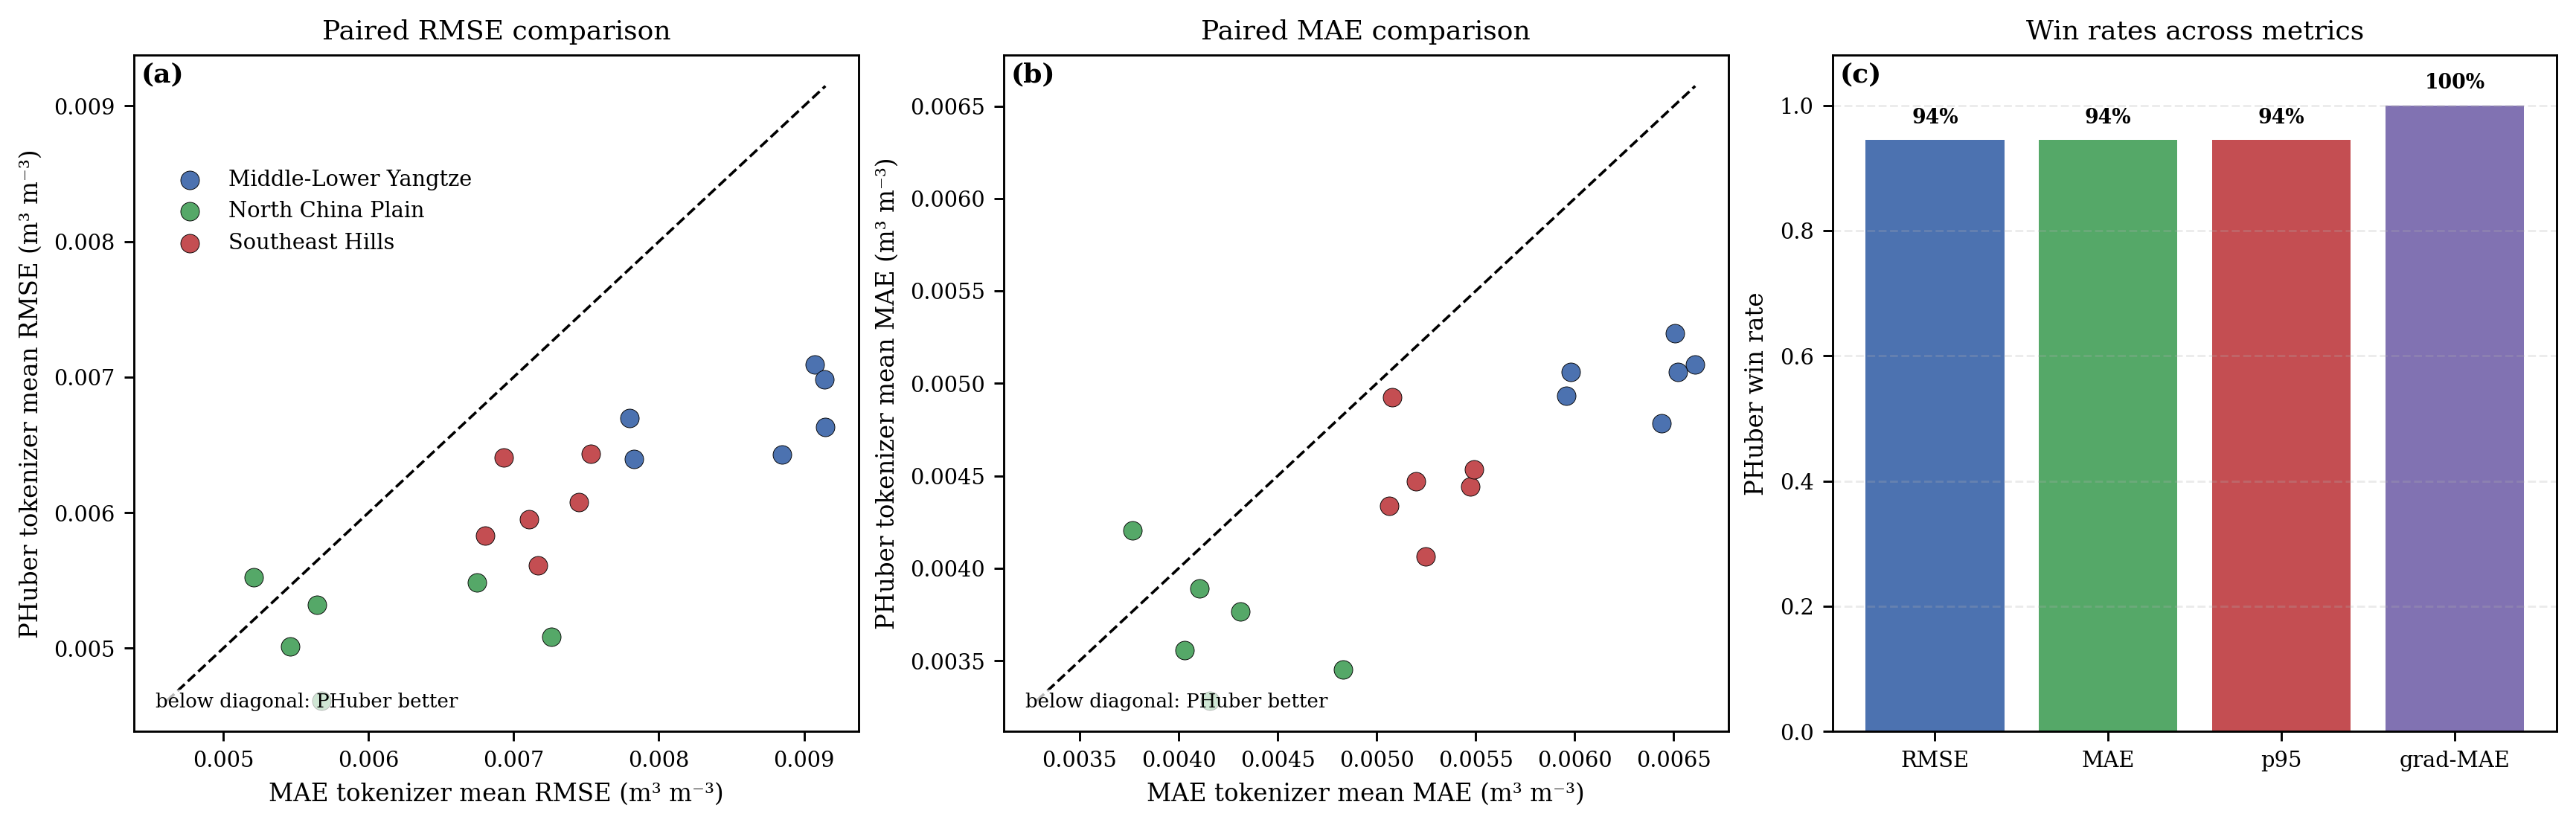


建议英文 caption：
Figure 2. Quantitative comparison of the stage-1 RZSM tokenizers. Panels (a) and (b) show paired crop-level RMSE and MAE for the MAE-based tokenizer versus the PHuber-based tokenizer; points below the diagonal favor the PHuber tokenizer. Panel (c) summarizes the fraction of benchmark crops for which the PHuber tokenizer outperforms the MAE tokenizer across four evaluation metrics. The corresponding mean old-minus-new improvements are reported in Table 1.

建议中文 caption：
图2. 第一阶段 RZSM tokenizer 的定量对比。子图 (a) 和 (b) 分别给出 crop 级别的 RMSE 和 MAE 配对散点图，横轴为 MAE tokenizer，纵轴为 PHuber tokenizer，落在对角线下方的点表示 PHuber tokenizer 更优。子图 (c) 给出 PHuber tokenizer 在四个评估指标上优于 MAE tokenizer 的样本比例；对应的平均 old-minus-new 改进值见表1。


In [2]:
set_seed(42)
ckpt_old = ROOT / 'models' / 'vae_mae_rzsm.ckpt'
ckpt_new = ROOT / 'models' / 'vae_phuber_rzsm.ckpt'
base_dir = ROOT / 'data' / '0.1' / '1' / 'land_surface'
output_dir = ROOT / 'outputs' / 'stage1_tokenizer_paper'
cases = default_cases()
search_cfg = SearchConfig(search_attempts=128, jitter_px=110, selection_mode='dynamic_near_roi')
benchmark_crops_per_case = 6
bench_df, bench_summary = make_benchmark_figure(
    ckpt_old=ckpt_old,
    ckpt_new=ckpt_new,
    cases=cases,
    base_dir=base_dir,
    output_dir=output_dir,
    benchmark_crops_per_case=benchmark_crops_per_case,
    search=search_cfg,
    save_stem='fig2_stage1_quantitative_comparison',
)
print('已生成定量对比图:', bench_summary['png_path'])
from IPython.display import Image, display
display(Image(filename=bench_summary['png_path']))

print('\n建议英文 caption：')
print(bench_summary['caption_en'])
print('\n建议中文 caption：')
print(bench_summary['caption_zh'])
